In [4]:
import sys 
sys.path.append("..")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from controllers.pid import PidController
from controllers.mpc_01 import MpcController
from controllers.rl import RlController
from sim.disturbance import Scenario, run_tracking_disturbance
from sim.plant import act, k
from sim.runner import tracking_metrics
from sim.trajectories import circle_ref, figure8_ref, waypoint_ref

scenarios = [
    Scenario("baseline"),
    Scenario("payload", mass=110.0, izz=15.4),
    Scenario("low_friction", mu_s=0.09, mu_k=0.07),
    Scenario("com_offset", com_x=-0.076),
    Scenario("actuator_noise", action_noise=3.0),
    Scenario("external_push", ext_force=(120.0,0.0), ext_window=(5.0,7.0)),
]

/Users/yashralhan/Projects/holonomic-control-benchmark/.venv/lib/python3.11/site-packages/do_mpc/sysid/__init__.py:15: UserWarning: The ONNX feature is not available. Please install the full version of do-mpc to access this feature.
  warnings.warn('The ONNX feature is not available. Please install the full version of do-mpc to access this feature.')
/Users/yashralhan/Projects/holonomic-control-benchmark/.venv/lib/python3.11/site-packages/do_mpc/opcua/__init__.py:14: UserWarning: The opcua feature is not available. Please install the full version of do-mpc to access this feature.
  warnings.warn('The opcua feature is not available. Please install the full version of do-mpc to access this feature.')


In [2]:
dt = 0.02
f_limit = 4*act["wheel_force_max_n"]
m_limit = f_limit*k
gains = {"kp": (60.0, 60.0, 0.0), "ki": (0.0, 0.0, 0.0), "kd": (130.0, 130.0, 28.0)}

def make_controller(cname,ref_fn):
    if cname == "pid":
        return PidController(gains, dt, f_limit, m_limit)
    if cname == "mpc":
        return MpcController(ref_fn, dt)
    if cname == "ppo":
        return RlController("../results/ppo_tracking", "ppo")
    if cname  == "sac":
        return RlController("../results/sac_tracking", "sac")
    if cname == "sac_dr":
        return RlController("../results/sac_dr_tracking", "sac")

In [3]:
controller_names = ["pid", "mpc", "ppo", "sac", "sac_dr"]
runs = [
    ("circle", circle_ref, 40.0),
    ("figure8", figure8_ref, 60.0),
    ("waypoints", lambda t: waypoint_ref(t, hold=8.0), 40.0),
]

rows = []
for s_idx, sc in enumerate(scenarios):
    for tname, ref_fn, dur in runs :
        for cname in controller_names:
            ctrl = make_controller(cname, ref_fn)
            res = run_tracking_disturbance(ctrl, ref_fn, dur, sc, seed=1000 + s_idx)
            rows.append({
                "controller" : cname,
                "trajectory" : tname,
                "scenario" : sc.name,
                **tracking_metrics(res),
            })
robust = pd.DataFrame(rows)
robust.to_csv("../results/robustness.csv", index = False)
robust


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************



,controller,trajectory,scenario,pos_rmse,heading_rmse,effort,compute_ms_mean,compute_ms_max
0,pid,circle,baseline,0.301985,1.442013e-01,16307.545806,0.008514,0.095625
1,mpc,circle,baseline,0.045107,1.117092e-02,14900.833860,2.700354,31.014083
2,ppo,circle,baseline,0.200273,1.617945e-01,12831.411444,0.085595,7.218084
3,sac,circle,baseline,0.504887,5.150707e-02,15001.458097,0.116703,2.219208
4,sac_dr,circle,baseline,0.620358,2.984092e-01,26095.134024,0.115258,0.211250
...,...,...,...,...,...,...,...,...
85,pid,waypoints,external_push,1.042353,1.278038e-15,28122.446310,0.008650,0.035584
86,mpc,waypoints,external_push,0.909007,1.148907e-01,65771.036840,3.031038,24.129667
87,ppo,waypoints,external_push,4.022983,1.042253e+00,107929.268381,0.081225,0.179583
88,sac,waypoints,external_push,49.840760,1.641729e+00,141132.434726,0.114427,0.180125


In [4]:
desired_scenarios = [
    "baseline", "payload", "low_friction", 
    "com_offset", "actuator_noise", "external_push"
]
pos = robust.pivot_table(index=["controller"], columns="scenario", values="pos_rmse", aggfunc="mean")
safe_columns = [col for col in desired_scenarios if col in pos.columns]
pos = pos[safe_columns]
pos.round(3)

scenario,baseline,payload,low_friction,com_offset,actuator_noise,external_push
controller,,,,,,
mpc,0.098,0.134,0.108,0.099,0.101,0.879
pid,0.383,0.471,0.390,0.387,0.385,1.625
ppo,0.448,0.485,0.435,0.455,0.453,7.518
sac,0.603,0.589,0.596,0.613,0.578,51.647
sac_dr,0.610,0.770,0.600,0.626,0.614,157.664


NameError: name 'pos' is not defined

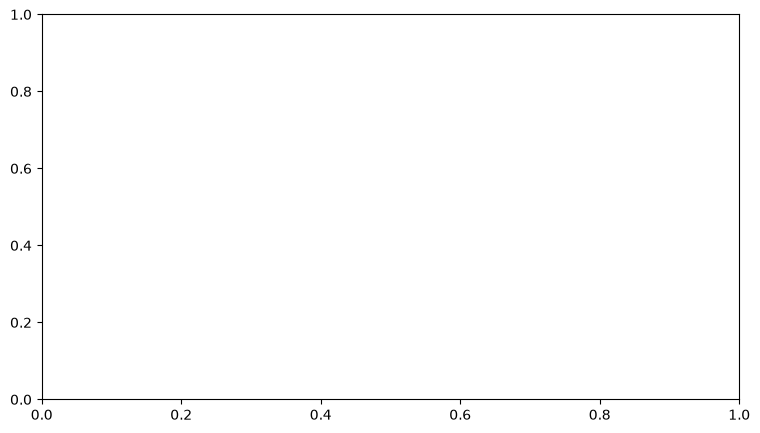

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
pos.T.plot(kind="bar", ax=ax)
ax.set_ylabel("position RMSE [m] (mean over trajectories)")
ax.set_xlabel("scenario")
plt.tight_layout()
fig.savefig("../results/robustness_pos_rmse.png", dpi=150)